In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re 
import mido
import os
import shutil

# Download and organize data

In [40]:
# ! git clone https://github.com/madelinehamilton/BiMMuDa.git data/

In [ ]:
# source_root = "data/BiMMuDA"
# destination = "all_midis"

# os.makedirs(destination, exist_ok=True)

# for root, dirs, files in os.walk(source_root):
#     for file in files:
#         if file.endswith(".mid"):
#             src_path = os.path.join(root, file)
#             dst_path = os.path.join(destination, file)
#             shutil.copy2(src_path, dst_path)

In [ ]:

# SOURCE_DIR = "all_midis"
# DEST_DIR = "clean_monophonic_midis"

# os.makedirs(DEST_DIR, exist_ok=True)

# def is_monophonic(midi_path):
#     try:
#         midi = mido.MidiFile(midi_path)
#     except Exception:
#         return False, "corrupted"

#     notes = []
#     current_time = 0

#     for track in midi.tracks:
#         current_time = 0
#         active_notes = {}

#         for msg in track:
#             current_time += msg.time

#             if msg.type == "note_on" and msg.velocity > 0 and msg.channel != 9:
#                 active_notes[msg.note] = current_time

#             elif (msg.type == "note_off") or (msg.type == "note_on" and msg.velocity == 0):
#                 if msg.note in active_notes:
#                     start = active_notes.pop(msg.note)
#                     end = current_time
#                     notes.append((start, end))

#     if len(notes) == 0:
#         return False, "no_notes"

#     # sort by start time
#     notes.sort(key=lambda x: x[0])

#     # check overlap
#     prev_end = notes[0][1]
#     for start, end in notes[1:]:
#         if start < prev_end:
#             return False, "polyphonic"
#         prev_end = max(prev_end, end)

#     return True, "monophonic"


# print("Cleaning MIDI dataset for IDyOM...\n")

# for file in os.listdir(SOURCE_DIR):
#     if file.endswith(".mid"):
        
#         # Skip files containing "full"
#         if "full" in file.lower():
#             print(f"Skipping {file} → contains 'full'")
#             continue
        
#         path = os.path.join(SOURCE_DIR, file)
#         ok, reason = is_monophonic(path)

#         if ok:
#             shutil.copy2(path, os.path.join(DEST_DIR, file))
#         else:
#             print(f"Skipping {file} → {reason}")

# print("\nDone.")

## Cross Validation Trend

In [ ]:
# To produce the output run this code, output will be saved in "out" folder which has been since renamed in this repo
# ! python3 IDyOM/App.py -c clean_monophonic_midis/

with open("cross_val_out/eval/data/likelihoods_cross-eval_k_fold_5_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle", "rb") as f:
    cross_val_surprisal = pickle.load(f)

cross_val_df = pd.DataFrame(cross_val_surprisal).drop(columns=["info"])

In [20]:
# --- Step 1: Compute per-song means ---
song_stats = []

for song in cross_val_df.columns:
    year = int(song[:4])  # extract year from filename
    
    surprisal_vector = cross_val_df.loc[0, song]
    entropy_vector = cross_val_df.loc[1, song]
    
    mean_surprisal = np.mean(surprisal_vector)
    mean_entropy = np.mean(entropy_vector)
    
    song_stats.append({
        "song": song,
        "year": year,
        "mean_surprisal": mean_surprisal,
        "mean_entropy": mean_entropy
    })

song_df = pd.DataFrame(song_stats)

# --- Step 2: Aggregate by year ---
cross_val_yearly_avg = (
    song_df
    .groupby("year")[["mean_surprisal", "mean_entropy"]]
    .mean()
    .reset_index()
    .sort_values("year")
)

print(cross_val_yearly_avg)

    year  mean_surprisal  mean_entropy
0   1950        4.406358      3.138299
1   1951        4.781330      3.560367
2   1952        4.461024      3.403464
3   1953        4.960273      3.605045
4   1954        4.255583      3.329353
..   ...             ...           ...
70  2020        3.618874      2.931633
71  2021        3.152493      2.692932
72  2022        3.110473      2.689270
73  2023        3.499404      2.974384
74  2024        3.664309      3.016401

[75 rows x 3 columns]


In [32]:
best_fit_slopes = []

Surprisal slope: -0.0199
Entropy slope: -0.0098


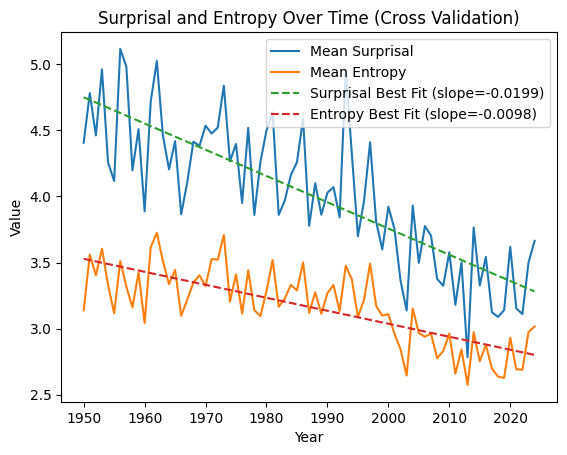

In [33]:
plt.figure()

plt.plot(cross_val_yearly_avg["year"], cross_val_yearly_avg["mean_surprisal"], label="Mean Surprisal")
plt.plot(cross_val_yearly_avg["year"], cross_val_yearly_avg["mean_entropy"], label="Mean Entropy")

years = cross_val_yearly_avg["year"]

for col, label in [("mean_surprisal", "Surprisal"), ("mean_entropy", "Entropy")]:
    coeffs = np.polyfit(years, cross_val_yearly_avg[col], deg=1)
    slope, intercept = coeffs
    best_fit = np.poly1d(coeffs)(years)
    
    plt.plot(years, best_fit, linestyle="--", label=f"{label} Best Fit (slope={slope:.4f})")
    best_fit_slopes.append({f"cross_val_{label}":slope})
    print(f"{label} slope: {slope:.4f}")
    

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Surprisal and Entropy Over Time (Cross Validation)")
plt.legend()

plt.show()

In [34]:
best_fit_slopes

[{'cross_val_Surprisal': -0.019850430137270666},
 {'cross_val_Entropy': -0.009818899879271849}]

## 5 Year Lookback Trend

In [ ]:
# To create these outputs, use the below command to organize midi files in respective folders:
# ! python3 organize_midis_by_5yr.py -i clean_monophonic_midis/ -o midis_by_5yr_window -w 4 -s 1

# To run the IDyOM function on these windows, run the below command 
# ! python3 run_eras_idyom.py -d midis_by_5yr_window -r 5yr_window_results

five_yr_lookback = []

for start_year in range(1950, 2020):  
    end_year = start_year + 4
    folder_start = start_year + 1
    folder_end = end_year + 1

    filepath = (
        f"5yr_window_out/{folder_start}-{folder_end}/surprises/"
        f"{start_year}-{end_year}/data/"
        f"{start_year}-{end_year}_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle"
    )

    with open(filepath, "rb") as f:
        data = pickle.load(f)
        
    df = pd.DataFrame(data)
    df = df.drop(columns=["info"])

    song_stats = []

    for song_segment in df.columns:
        song_segment_split = re.split('_', song_segment)
        year = int(song_segment_split[0])  
        song_id = song_segment_split[1]
        segment_id = song_segment_split[0]
        year_position = str(year) +"_" + song_id
        surprisal_vector = df.loc[0, song_segment]
        entropy_vector = df.loc[1, song_segment]
        
        mean_surprisal = np.mean(surprisal_vector)
        mean_entropy = np.mean(entropy_vector)
        
        song_stats.append({
            "song": song_segment,
            "year": year,
            "year_position": year_position,
            "mean_surprisal": mean_surprisal,
            "mean_entropy": mean_entropy
        })

    song_df = pd.DataFrame(song_stats)
    # merged_df = pd.merge(song_df, genre_subset, on="year_position", how= "left")

    # --- Step 2: Aggregate by year ---
    yearly_stats = (
        song_df
        .groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )
    
    five_yr_lookback.append(yearly_stats.iloc[-1])
    
five_yr_lookback = pd.DataFrame(five_yr_lookback)
five_yr_lookback


,year,mean_surprisal,mean_entropy
4,1955.0,4.140432,3.094362
4,1956.0,5.107264,3.549987
4,1957.0,9.522592,3.398589
4,1958.0,4.795288,3.225394
4,1959.0,4.682121,3.499601
...,...,...,...
4,2020.0,3.911545,2.721305
4,2021.0,3.366579,2.513096
4,2022.0,3.521129,2.503355
4,2023.0,3.661760,2.769175


Surprisal slope: -0.0277
Entropy slope: -0.0151


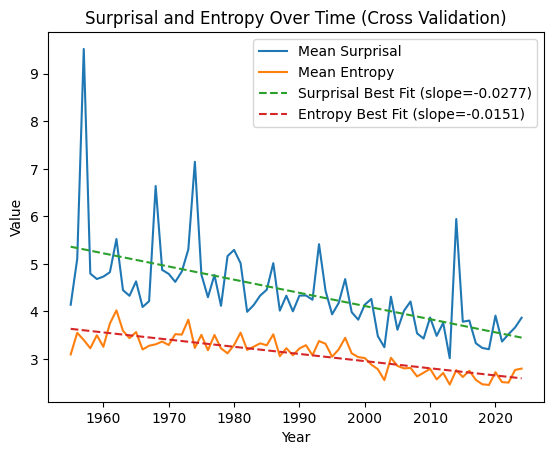

In [37]:
plt.figure()

plt.plot(five_yr_lookback["year"], five_yr_lookback["mean_surprisal"], label="Mean Surprisal")
plt.plot(five_yr_lookback["year"], five_yr_lookback["mean_entropy"], label="Mean Entropy")

years = five_yr_lookback["year"]

for col, label in [("mean_surprisal", "Surprisal"), ("mean_entropy", "Entropy")]:
    coeffs = np.polyfit(years, five_yr_lookback[col], deg=1)
    slope, intercept = coeffs
    best_fit = np.poly1d(coeffs)(years)
    
    plt.plot(years, best_fit, linestyle="--", label=f"{label} Best Fit (slope={slope:.4f})")
    best_fit_slopes.append({f"five_yr_lookback_{label}":slope})
    print(f"{label} slope: {slope:.4f}")
    

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Surprisal and Entropy Over Time (Cross Validation)")
plt.legend()

plt.show()

## 10 Year Lookback Trend

In [ ]:
# Run these 2 commands first to get data for this plot
# ! python3 organize_midis_by_5yr.py -i clean_monophonic_midis -o midis_by_10yr_window -w 9 -s 1
# ! python3 run_eras_idyom.py -d midis_by_10yr_window -r out/

ten_yr_lookback = []

for start_year in range(1950, 2013):  
    end_year = start_year + 9
    folder_start = start_year + 1
    folder_end = end_year + 1

    filepath = (
        f"10yr_window_out/eval_{folder_end}/surprises/"
        f"{start_year}-{end_year}/data/"
        f"{start_year}-{end_year}_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle"
    )

    with open(filepath, "rb") as f:
        data = pickle.load(f)
        
    df = pd.DataFrame(data)
    df = df.drop(columns=["info"])

    song_stats = []

    for song_segment in df.columns:
        song_segment_split = re.split('_', song_segment)
        year = int(song_segment_split[0])  
        song_id = song_segment_split[1]
        segment_id = song_segment_split[0]
        year_position = str(year) +"_" + song_id
        surprisal_vector = df.loc[0, song_segment]
        entropy_vector = df.loc[1, song_segment]
        
        mean_surprisal = np.mean(surprisal_vector)
        mean_entropy = np.mean(entropy_vector)
        
        song_stats.append({
            "song": song_segment,
            "year": year,
            "year_position": year_position,
            "mean_surprisal": mean_surprisal,
            "mean_entropy": mean_entropy
        })

    song_df = pd.DataFrame(song_stats)
    # merged_df = pd.merge(song_df, genre_subset, on="year_position", how= "left")

    # --- Step 2: Aggregate by year ---
    yearly_stats = (
        song_df
        .groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )
    
    ten_yr_lookback.append(yearly_stats.iloc[-1])
    
ten_yr_lookback = pd.DataFrame(ten_yr_lookback)
ten_yr_lookback
    